In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.io import loadmat
from scipy.io import savemat
import os
from metpy.calc import saturation_mixing_ratio
from metpy.units import units
from newcasenum import newcasenum
from newlab import newlab
from metpy.calc import static_stability
from metpy.calc import moist_lapse
from metpy.calc import potential_temperature
from metpy.calc import virtual_temperature
from metpy.calc import surface_based_cape_cin,dewpoint_from_relative_humidity
from metpy.units import units
import xarray as xr

In [11]:
def pickcases(val):
    casenums = np.array(['f299rd2','f299rx1','f299rx3d2', 'f299rx2', 'f299rx3', 'f302rd2','fixedn1', 'f302rx3d2b',
             'fixedn1x2', 'f302rx3', 'f303rd2', 'f303r1', 'f303rx3d2','f303rx2','f303rx3',
             'f305rd2', 'fixedn1p3', 'f305rx3d2', 'f305rx2','f305rx3'])
    indssts = np.array([1,1,1, 1, 1, 2,2, 2, 2, 2, 3,3,3, 3, 3, 4,4, 4, 4, 4])
    indranges = np.array([1,2,3, 4, 5, 1,2, 3, 4, 5, 1, 2, 3,4,5, 1, 2, 3, 4,5])
    ssts = np.array(['299', '302', '303.5','305'])
    ranges = np.array(['2.5','5','7.5','10','15'])
    if val in ssts:
        ind = np.nonzero(ssts==val)[0][0]+1
        subcases = casenums[indssts==ind]
    elif val in ranges:
        ind = np.nonzero(ranges==val)[0][0]+1
        subcases = casenums[indranges==ind]
    else:
        subcases = casenums
        
    return subcases

def gradsmap():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
def gradsmapf():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [10, 50, 120],
        [15, 75, 165],
        [30, 110, 200],
        [60, 160, 240],
        [80, 180, 250],
        [130, 210, 255],
        [160, 240, 255],
        [200, 250, 255],
        [230, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(np.flipud(gradsmap2))
    
    return cmap


def gradsmap0():
    # Define the colormap matrix
    gradsmap2 = np.array([
        [255, 255, 255],
        [255, 250, 220],
        [255, 232, 120],
        [255, 192, 60],
        [255, 160, 0],
        [255, 96, 0],
        [255, 50, 0],
        [225, 20, 0],
        [192, 0, 0],
        [165, 0, 0]
    ]) / 255.0  # Normalize to [0, 1] range
    
    # Create a colormap from the array
    cmap = mcolors.ListedColormap(gradsmap2)
    
    return cmap
def getdeltas(ccases,stuff):
    path = '/home/disk/eos8/bdygert/code/compredo/'
    cn=len(ccases)
    deltas = np.zeros((cn,1))
    for j in range(cn):
        casenum = ccases[j]
        flnm = path + casenum+stuff+'2dcrh.mat'
        data = loadmat(flnm)
        pstuff = data['stf']
        deltas[j]=np.nanmax(pstuff)-np.nanmin(pstuff)

    return deltas
def plotsstlines(ccases,stuff):
    path = '/home/disk/eos8/bdygert/code/compredo/'
    colors = plt.cm.bwr(np.linspace(0,1,4))
    ssts = np.array(['299', '302', '303.5','305'])
    cn=len(ccases)
    deltas = np.zeros((cn,1))
    for j in range(cn):
        casenum = ccases[j]
        flnm = path + casenum+stuff+'2dcrh.mat'
        data = loadmat(flnm)
        pstuff = data['stf']
        pstuff = np.mean(pstuff,2)
        deltas[j]=np.nanmax(pstuff)-np.nanmin(pstuff)

    return deltas
def readstf(ccase,cvar):
    path = '/home/disk/eos8/bdygert/code/compredo/'
    flnm = path + ccase+cvar+'2dcrh.mat'
    data = loadmat(flnm)
    pstuff = data['stf']
    #p = data['pfull']
    
    return pstuff

def readnetcdf(ccase,cvar):
    path = '/home/disk/eos7/bdygert/aquafv/output/'
    flnm = path + ccase+'/history/'+ccase+'months.nc'
    data = xr.open_dataset(flnm,decode_times=False)
    pstuff = data[cvar].to_numpy()
    #p = data['pfull']
    
    return pstuff
    

In [ ]:
#Average only over subsiding region
def vavg_sub(ccase,cvar,vreg):
    aa=0
    ab=20
    if vreg==0:
        #848 to 600 hPa
        #pa=8
        #pa=0
        #pb=14
        #pa = 18
        pa = 17
        #pb = 24
        pb = 31
        #print('low')
    elif vreg==2:
        pa=0
        pb=15
        #print('high')
    elif vreg==3:
        pa = 15
        pb = 19
    elif vreg==4:
        pa = 15
        pb = 22
    else:
        pa=0
        pb=31

    #phalf = np.flip(readnetcdf(ccase,'phalf'))[:-1]
    #p=np.flip(readnetcdf(ccase,'pfull'))
    phalf = readnetcdf(ccase,'phalf')[:-1]
    p = readnetcdf(ccase,'pfull')
    print(p[pa:pb])
    dp = np.gradient(phalf)
    stf = readstf(ccase,cvar)
    #if cvar=='ucomptc':
    #    stf[stf>0]=np.nan
    doplot=0
    if doplot:
        if cvar=='stf':
            plt.plot(stf[0,:],p)
            plt.scatter(stf[0,pa:pb],p[pa:pb])
        else:
            plt.plot(stf[0,:,0],p)
            plt.scatter(stf[0,pa:pb,0],p[pa:pb])
        plt.grid("True")
    if len(np.shape(stf))>2:
        stf = np.mean(stf,2)
    stf = stf[aa:ab,pa:pb]
    dp = dp[pa:pb]
    np.shape(np.multiply(stf,dp))
    val = np.nansum(np.multiply(stf,dp))/np.nansum(dp)        
    return val
def vavg_sum(ccase,cvar,vreg):
    if vreg==0:
        #848 to 600 hPa
        #pa=8
        #pa=0
        #pb=14
        #pa = 18
        pa = 17
        #pb = 24
        pb = 31
        #print('low')
    elif vreg==2:
        pa=0
        pb=15
        #print('high')
    elif vreg==3:
        pa = 15
        pb = 19
    elif vreg==4:
        pa = 16
        pb = 23
    else:
        pa=0
        pb=31

    #phalf = np.flip(readnetcdf(ccase,'phalf'))[:-1]
    #p=np.flip(readnetcdf(ccase,'pfull'))
    phalf = readnetcdf(ccase,'phalf')[:-1]
    p = readnetcdf(ccase,'pfull')
    print(p[pa:pb])
    dp = np.gradient(phalf)
    stf = readstf(ccase,cvar)
    if cvar=='ucomptc':
        stf[stf>0]=np.nan
    doplot=0
    if doplot:
        if cvar=='stf':
            plt.plot(stf[0,:],p)
            plt.scatter(stf[0,pa:pb],p[pa:pb])
        else:
            plt.plot(stf[0,:,0],p)
            plt.scatter(stf[0,pa:pb,0],p[pa:pb])
        plt.grid("True")
    if len(np.shape(stf))>2:
        stf = np.mean(stf,2)
    stf = np.nansum(stf[:,pa:pb],0)
    dp = dp[pa:pb]
    np.shape(np.multiply(stf,dp))
    val = np.nansum(np.multiply(stf,dp))/np.nansum(dp)        
    return val
def getvals_sub(vcases,vstuff,vheight,donorm):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        vals[j]=vavg_sub(casenum,vstuff,vheight)
        if donorm!=0:
            vals[j] = vals[j]/vavg(casenum,vstuff,donorm)
    return vals
def getvals_sum(vcases,vstuff,vheight,donorm):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        vals[j]=vavg_sum(casenum,vstuff,vheight)
        if donorm!=0:
            vals[j] = vals[j]/vavg(casenum,vstuff,donorm)
    return vals

In [12]:
def vavg(ccase,cvar,vreg):
    if vreg==0:
        #848 to 600 hPa
        #pa=8
        #pa=0
        #pb=14
        #pa = 18
        pa = 17
        #pb = 24
        pb = 31
        #print('low')
    elif vreg==2:
        pa=0
        pb=15
        #print('high')
    elif vreg==3:
        pa = 15
        pb = 19
    elif vreg==4:
        pa = 19
        pb = 24
    else:
        pa=0
        pb=31

    #phalf = np.flip(readnetcdf(ccase,'phalf'))[:-1]
    #p=np.flip(readnetcdf(ccase,'pfull'))
    phalf = readnetcdf(ccase,'phalf')[:-1]
    p = readnetcdf(ccase,'pfull')
    #print(p[pa:pb])
    dp = np.gradient(phalf)
    stf = readstf(ccase,cvar)
    #if cvar=='ucomptc':
    #    stf[stf>0]=np.nan
    doplot=0
    if doplot:
        if cvar=='stf':
            plt.plot(stf[0,:],p)
            plt.scatter(stf[0,pa:pb],p[pa:pb])
        else:
            plt.plot(stf[0,:,0],p)
            plt.scatter(stf[0,pa:pb,0],p[pa:pb])
        plt.grid("True")
    if len(np.shape(stf))>2:
        stf = np.mean(stf,2)
    stf = stf[:,pa:pb]
    dp = dp[pa:pb]
    np.shape(np.multiply(stf,dp))
    val = np.nansum(np.multiply(stf,dp))/np.nansum(dp)        
    return val
def getvals(vcases,vstuff,vheight,donorm):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        vals[j]=vavg(casenum,vstuff,vheight)
        if donorm!=0:
            vals[j] = vals[j]/vavg(casenum,vstuff,donorm)
    return vals
def getvals_single(vcases,vstuff,vlevel,normlevel):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        stf = readstf(casenum,vstuff)
        if len(np.shape(stf))>2:
            stf = np.mean(stf,2)
        vals[j]=np.nanmean(stf[:,vlevel])
        if normlevel!=0:
            vals[j] = vals[j]/np.nanmean(stf[:,normlevel])
    return vals

In [ ]:
def vavg_min(ccase,cvar,vreg):
    if vreg==0:
        #Min below 500
        pa = 17
        pb = 31
    elif vreg==1:
        #Min below 600?
        pa = 18
        pb = 31
    else:
        pa=0
        pb=31

    #phalf = np.flip(readnetcdf(ccase,'phalf'))[:-1]
    #p=np.flip(readnetcdf(ccase,'pfull'))
    phalf = readnetcdf(ccase,'phalf')[:-1]
    p = readnetcdf(ccase,'pfull')
    #print(p[pa:pb])
    dp = np.gradient(phalf)
    stf = readstf(ccase,cvar)
    #if cvar=='ucomptc':
    #    stf[stf>0]=np.nan
    doplot=0
    if doplot:
        if cvar=='stf':
            plt.plot(stf[0,:],p)
            plt.scatter(stf[0,pa:pb],p[pa:pb])
        else:
            plt.plot(stf[0,:,0],p)
            plt.scatter(stf[0,pa:pb,0],p[pa:pb])
        plt.grid("True")
    if len(np.shape(stf))>2:
        stf = np.mean(stf,2)
    stf = stf[:,pa:pb]
    dp = dp[pa:pb]
    stf[np.isnan(stf)]=9e9
    val = np.nanmean(stf.min(axis=0))
    #np.shape(np.multiply(stf,dp))
    #val = np.nansum(np.multiply(stf,dp))/np.nansum(dp)        
    return val
def getvals_min(vcases,vstuff,vheight,donorm):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        vals[j]=vavg_min(casenum,vstuff,donorm)
        if donorm!=0:
            vals[j] = vals[j]/vavg(casenum,vstuff,donorm)
    return vals

In [ ]:
def getmax(vcases,vstuff,getmean):
    cn=len(vcases)
    vals = np.zeros((cn,1))
    for j in range(cn):
        casenum = vcases[j]
        if getmean==0:
            vals[j] = np.nanmax(np.nanmax(np.nanmax(readnetcdf(casenum,vstuff))))
        else:
            vals[j] = np.nanmean(np.nanmean(np.nanmean(readnetcdf(casenum,vstuff))))

    return vals

0
1
2
3


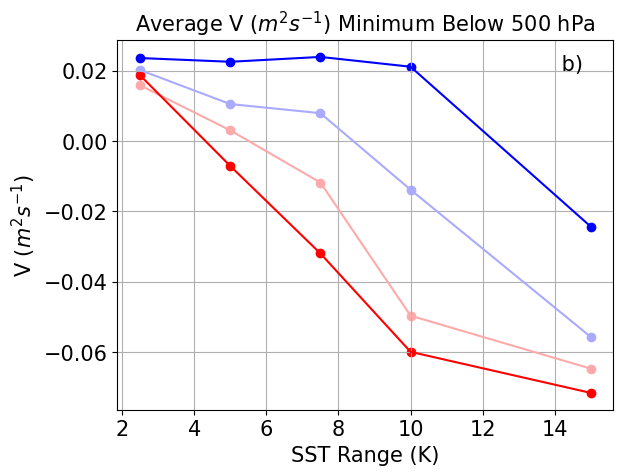

In [13]:
#Plot vals by SST
cnorm=0
vh=0
#dvar='ucomptc'
dvar ='dstfdp'
fname = dvar+'dstfdpplotc.pdf'
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
colors = plt.cm.bwr(np.linspace(0,1,4))
nranges = [float(r) for r in ranges]
#vstr='Average U Minimum (m/s): below 500 hPa'
vstr = 'Average V $(m^2s^{-1})$ Minimum Below 500 hPa'
ystr = 'V $(m^2s^{-1})$'
sc = 1

for c in range (0,4):
    ccasenums=pickcases(ssts[c])
    dcs = getvals_min(ccasenums,dvar,0,cnorm)
    print(c)
    plt.scatter(nranges,sc*dcs,color=colors[c],label=ssts[c])
    plt.plot(nranges,sc*dcs,color=colors[c])
    #print(np.corrcoef(nranges,dcs.ravel())[0,1])
#plt.legend(loc = 'lower right',facecolor = 'none',edgecolor='none',fontsize=15)

plt.text(14, .02, ' b)', fontsize=15)#,horizontalalignment='left', verticalalignment='top')#, transform=plt.transAxes)
#plt.xlabel('Global Mean SST (K)')
plt.xlabel('SST Range (K)',fontsize=15)
plt.title(vstr,fontsize=15)
plt.ylabel(ystr,fontsize=15)
plt.rcParams['font.size'] = 15
plt.grid(True)
plt.savefig(fname, dpi=400,bbox_inches='tight')
#dosave =1
#if dosave:
#    fname = 'fixedsststfval.pdf'
#    plt.savefig(fname, dpi=400)
plt.show()

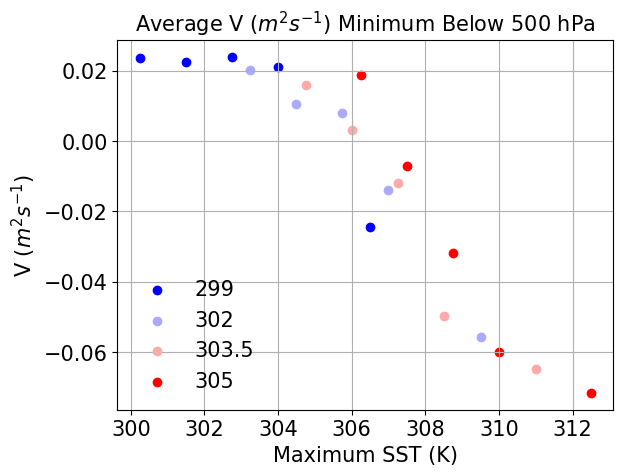

In [14]:
#Plot vals by SST
cnorm=0
vh=0
#dvar='ucomptc'
dvar ='dstfdp'
fname = dvar+'tmaxb.pdf'
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
colors = plt.cm.bwr(np.linspace(0,1,4))
nranges = [float(r) for r in ranges]
#vstr='Average U Minimum (m/s): below 500 hPa'
vstr = 'Average V $(m^2s^{-1})$ Minimum Below 500 hPa'
ystr = 'V $(m^2s^{-1})$'
sc = 1

for c in range (0,4):
    ccasenums=pickcases(ssts[c])
    dcs = getvals_min(ccasenums,dvar,0,cnorm)
    maxes = maxes=getmax(ccasenums,'t_surf',0)
    plt.scatter(maxes,sc*dcs,color=colors[c],label=ssts[c])
    #plt.plot(nranges,sc*dcs,color=colors[c])
    #print(np.corrcoef(nranges,dcs.ravel())[0,1])
plt.legend(loc = 'lower left',facecolor = 'none',edgecolor='none',fontsize=15)

#plt.text(14, .02, ' b)', fontsize=15)#,horizontalalignment='left', verticalalignment='top')#, transform=plt.transAxes)
#plt.xlabel('Global Mean SST (K)')
plt.xlabel('Maximum SST (K)',fontsize=15)
plt.title(vstr,fontsize=15)
plt.ylabel(ystr,fontsize=15)
plt.rcParams['font.size'] = 15
plt.grid(True)
plt.savefig(fname, dpi=400,bbox_inches='tight')
#dosave =1
#if dosave:
#    fname = 'fixedsststfval.pdf'
#    plt.savefig(fname, dpi=400)
plt.show()

0
1
2
3


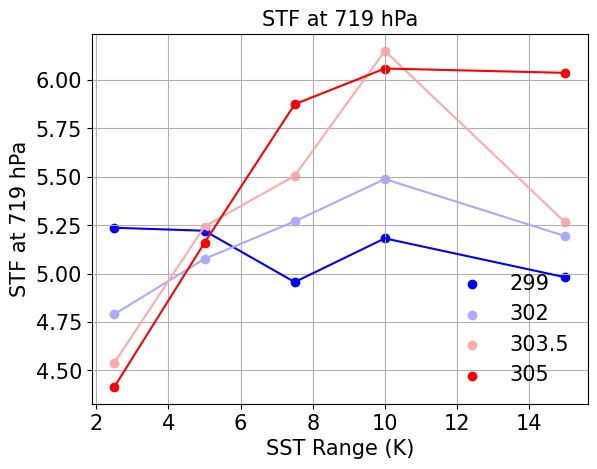

In [16]:
#Plot vals by SST
vlev=20
nlev=0
fname = 'lowstfsingle.pdf'
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
colors = plt.cm.bwr(np.linspace(0,1,4))
nranges = [float(r) for r in ranges]
p = readnetcdf('fixedn1','pfull')
vstr='STF at '+ str(round(p[vlev]))+ ' hPa'


for c in range (0,4):
    ccasenums=pickcases(ssts[c])
    dcs = getvals_single(ccasenums,'stf',vlev,nlev)
    print(c)
    plt.scatter(nranges,dcs,color=colors[c],label=ssts[c])
    plt.plot(nranges,dcs,color=colors[c])
    #print(np.corrcoef(nranges,dcs.ravel())[0,1])
plt.legend(loc = 'lower right',facecolor = 'none',edgecolor='none',fontsize=15)
#plt.text(2.5, .6, ' b)', fontsize=15)#,horizontalalignment='left', verticalalignment='top')#, transform=plt.transAxes)
#plt.xlabel('Global Mean SST (K)')
plt.xlabel('SST Range (K)',fontsize=15)
plt.title(vstr,fontsize=15)
plt.ylabel(vstr,fontsize=15)
plt.rcParams['font.size'] = 15
plt.grid(True)
plt.savefig(fname, dpi=400)
#dosave =1
#if dosave:
#    fname = 'fixedsststfval.pdf'
#    plt.savefig(fname, dpi=400)
plt.show()

0
0.9970610336646826
1
0.9985298772751953
2
0.9806800783415642
3
0.977405172784214


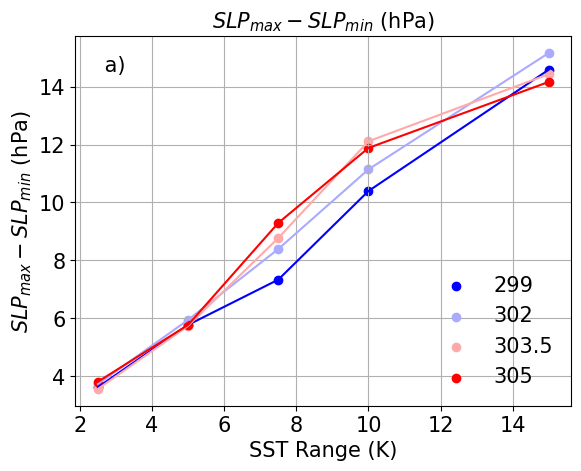

In [17]:
#Plot deltas by SST
dosave =1
fname = 'fixedsstslpvala.pdf'
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
colors = plt.cm.bwr(np.linspace(0,1,4))
nranges = [float(r) for r in ranges]
vstr='$SLP_{max}-SLP_{min}$ (hPa)'
for c in range (0,4):
    ccasenums=pickcases(ssts[c])
    dcs = getdeltas(ccasenums,'slp')
    print(c)
    plt.scatter(nranges,dcs,color=colors[c],label=ssts[c])
    plt.plot(nranges,dcs,color=colors[c])
    print(np.corrcoef(nranges,dcs.ravel())[0,1])
plt.text(2.5, 14.5, ' a)', fontsize=15)#,horizontalalignment='left', verticalalignment='top')#, transform=plt.transAxes)
plt.legend(loc = 'lower right',facecolor = 'none',edgecolor='none',fontsize=15)
#plt.xlabel('Global Mean SST (K)')
plt.xlabel('SST Range (K)',fontsize=15)
plt.title(vstr,fontsize=15)
plt.rcParams['font.size'] = 15
plt.grid(True)

plt.ylabel(vstr,fontsize=15)
plt.savefig(fname, dpi=400,bbox_inches='tight')

plt.show()
#if dosave:
#    fname = 'fixedsstslpval.pdf'
#    plt.savefig(fname, dpi=400)

0
1
2
3
4


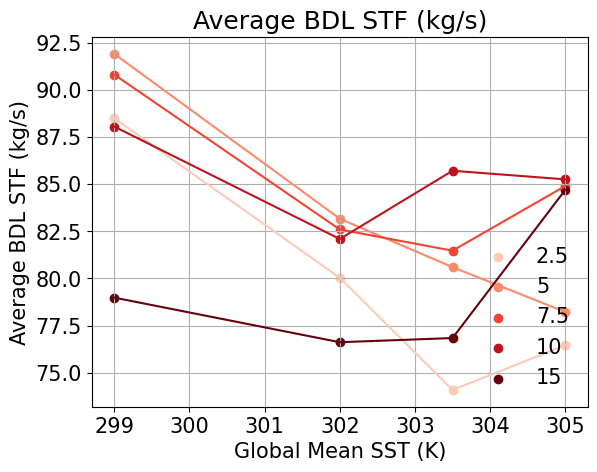

In [18]:
#Plot vals by SST
cnorm = 0
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
nssts = [float(r) for r in ssts]
vstr='Average BDL STF (kg/s)'
colors = plt.cm.Reds(np.linspace(0,1,6))
colors = colors[1:]
if cnorm:
    vstr = '$STF_{low}/STF_{total}$'
for c in range (0,5):
    ccasenums=pickcases(ranges[c])
    dcs = getvals(ccasenums,'stf',0,0)
    print(c)
    plt.scatter(nssts,dcs,color=colors[c],label=ranges[c])
    plt.plot(nssts,dcs,color=colors[c])
    #print(np.corrcoef(nranges,dcs.ravel())[0,1])
plt.legend(loc = 'lower right',facecolor = 'none',edgecolor='none')
plt.xlabel('Global Mean SST (K)')
#plt.xlabel('SST Range (K)')
plt.title(vstr)
plt.grid(True)

plt.ylabel(vstr)
plt.show()

Correlation Coefficient: 
0.4600128112486999
Correlation Coefficient: 
-0.140973582309798
Correlation Coefficient: 
0.9984353064989344
Correlation Coefficient: 
0.9294870362670714
Correlation Coefficient: 
-0.4624593987730071


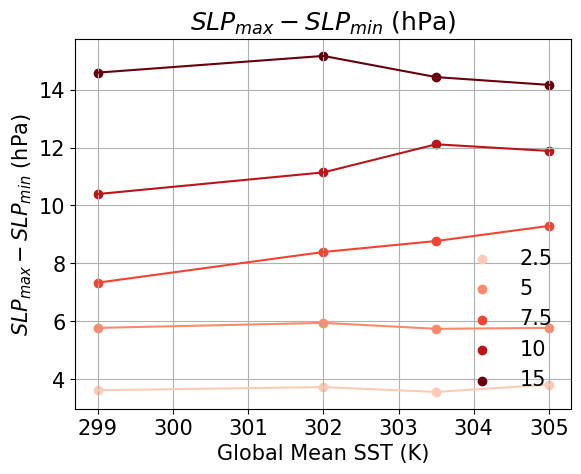

In [19]:
#Plot deltas by range
vstr='$SLP_{max}-SLP_{min}$ (hPa)'
ssts = np.array(['299', '302', '303.5','305'])
ranges = np.array(['2.5','5','7.5','10','15'])
colors = plt.cm.Reds(np.linspace(0,1,6))
nssts = [float(r) for r in ssts]
colors = colors[1:]
for c in range (0,5):
    ccasenums=pickcases(ranges[c])
    dcs = getdeltas(ccasenums,'slp')
    plt.scatter(nssts,dcs,color=colors[c],label=ranges[c])
    plt.plot(nssts,dcs,color=colors[c])
    print('Correlation Coefficient: ')
    print(np.corrcoef(nssts,dcs.ravel())[0,1])
plt.legend(loc = 'lower right',facecolor = 'none',edgecolor='none')
plt.xlabel('Global Mean SST (K)')
#plt.xlabel('SST Range (K)')
plt.title(vstr)
plt.grid(True)

plt.ylabel(vstr)
plt.show()
